In [ ]:
!pip install torch torchvision torchaudio

In [41]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import math
import time
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import time
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

In [42]:
x_train = pd.read_csv("X_train 2.csv")
y_train = pd.read_csv("y_train 2.csv")
x_val = pd.read_csv("X_val 2.csv")
y_val = pd.read_csv("y_val 2.csv")
x_test = pd.read_csv("X_test 2.csv")
y_test = pd.read_csv("y_test 2.csv")

In [6]:
print("x_train_dimension:", x_train.shape)

x_train_dimension: (183861, 3)


In [43]:

x_train_sampled = x_train.sample(n=60000, random_state=42)
y_train_sampled = y_train.loc[x_train_sampled.index]


x_val_sampled = x_val.sample(n=10000, random_state=42)
y_val_sampled = y_val.loc[x_val_sampled.index]

x_test_sampled = x_test.sample(n=10000, random_state=42)
y_test_sampled = y_test.loc[x_test_sampled.index]


In [5]:
# Print dimensions
print("Dimensions:")
print("x_train_sampled:", x_train_sampled.shape)
print("y_train_sampled:", y_train_sampled.shape)
print("x_val_sampled:", x_val_sampled.shape)
print("y_val_sampled:", y_val_sampled.shape)
print("x_test_sampled:", x_test_sampled.shape)
print("y_test_sampled:", y_test_sampled.shape)

# Print 2 samples from each
print("\nSample Data:")
print("x_train_sampled:\n", x_train_sampled.head(2))
print("y_train_sampled:\n", y_train_sampled.head(2))

print("x_val_sampled:\n", x_val_sampled.head(2))
print("y_val_sampled:\n", y_val_sampled.head(2))

print("x_test_sampled:\n", x_test_sampled.head(2))
print("y_test_sampled:\n", y_test_sampled.head(2))


Dimensions:
x_train_sampled: (60000, 3)
y_train_sampled: (60000, 1)
x_val_sampled: (10000, 3)
y_val_sampled: (10000, 1)
x_test_sampled: (10000, 3)
y_test_sampled: (10000, 1)

Sample Data:
x_train_sampled:
                                                     Tweet  \
161415  Here's a freedom convoy that everyone can get ...   
14305   WTF does the Freedom Convoy have to do with fa...   

                                            Cleaned_Tweet  \
161415  here's a freedom convoy that everyone can get ...   
14305   what the fuck does the freedom convoy have to ...   

                                      Final_Cleaned_Tweet  
161415              's freedom convoy everyone get behind  
14305   fuck freedom convoy farmer deal farm credit il...  
y_train_sampled:
        Sentiment
161415  positive
14305   negative
x_val_sampled:
                                                    Tweet  \
11499  Iâm speechless, sitting in a Senate office t...   
6475   Now US Official Nuland âQuite Co

In [44]:
# Fit on train only
label_encoder = LabelEncoder()
label_encoder.fit(y_train_sampled['Sentiment'])

# Transform all sets
y_train_enc = label_encoder.transform(y_train_sampled['Sentiment'])
y_val_enc = label_encoder.transform(y_val_sampled['Sentiment'])
y_test_enc = label_encoder.transform(y_test_sampled['Sentiment'])

In [9]:
print(y_train_enc[0])

2


In [45]:
#Tokenization
train_tokens = x_train_sampled['Final_Cleaned_Tweet'].fillna("").astype(str).apply(str.split)
val_tokens = x_val_sampled['Final_Cleaned_Tweet'].fillna("").astype(str).apply(str.split)
test_tokens = x_test_sampled['Final_Cleaned_Tweet'].fillna("").astype(str).apply(str.split)

In [46]:
# 1. Build vocabulary from training tokens
vocab = {'<PAD>': 0, '<UNK>': 1}
for tokens in train_tokens:
    for token in tokens:
        if token not in vocab:
            vocab[token] = len(vocab)

print(f"✅ Vocabulary size: {len(vocab)}")

✅ Vocabulary size: 32140


In [47]:
# Convert tokens to indices
def to_indices(token_list):
    return token_list.apply(lambda tokens: [vocab.get(token, vocab['<UNK>']) for token in tokens])

train_indices = to_indices(train_tokens)
val_indices = to_indices(val_tokens)
test_indices = to_indices(test_tokens)

In [48]:
# Pad sequences
def pad_seqs(indexed_seqs, max_len=50):
    seqs = [torch.tensor(seq[:max_len]) for seq in indexed_seqs]
    padded = pad_sequence(seqs, batch_first=True, padding_value=vocab['<PAD>'])
    if padded.shape[1] < max_len:
        pad_len = max_len - padded.shape[1]
        pad_tensor = torch.full((padded.shape[0], pad_len), vocab['<PAD>'], dtype=torch.long)
        padded = torch.cat([padded, pad_tensor], dim=1)
    return padded

X_train = pad_seqs(train_indices)
X_val = pad_seqs(val_indices)
X_test = pad_seqs(test_indices)

In [49]:
y_train = torch.tensor(y_train_enc, dtype=torch.long)
y_val = torch.tensor(y_val_enc, dtype=torch.long)
y_test = torch.tensor(y_test_enc, dtype=torch.long)

In [50]:
from torch.utils.data import Dataset

class TweetDataset(Dataset):
    def __init__(self, X, y):
        # Convert X to tensor if needed
        if not isinstance(X, torch.Tensor):
            if isinstance(X, np.ndarray):
                X = torch.tensor(X, dtype=torch.long)
            elif isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
                X = torch.tensor(X.values, dtype=torch.long)

        # Convert y to tensor if needed
        if not isinstance(y, torch.Tensor):
            if isinstance(y, np.ndarray):
                y = torch.tensor(y, dtype=torch.long)
            elif isinstance(y, pd.DataFrame) or isinstance(y, pd.Series):
                y = torch.tensor(y.values, dtype=torch.long)

        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [51]:
from torch.utils.data import DataLoader

# Initialize datasets
train_dataset = TweetDataset(X_train, y_train)
val_dataset = TweetDataset(X_val, y_val)
test_dataset = TweetDataset(X_test, y_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [52]:
# Positional Encoding class
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

In [16]:

class CausalTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, num_classes, max_len, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim, max_len)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=512,
            dropout=dropout,
            activation='relu',
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def generate_causal_mask(self, seq_len, device):
        mask = torch.triu(torch.ones(seq_len, seq_len) * float('-inf'), diagonal=1)
        return mask.to(device)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoding(x)

        seq_len = x.size(1)
        device = x.device
        causal_mask = self.generate_causal_mask(seq_len, device)

        x = self.encoder(x, mask=causal_mask)
        x = x.mean(dim=1)  # Global average pooling
        x = self.dropout(x)
        return self.classifier(x)


In [23]:
##Train and evaluate
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    y_true, y_pred, y_scores = [], [], []
    total_loss = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            y_scores.append(outputs.softmax(dim=1).cpu())
            y_true.append(labels.cpu())
            y_pred.append(outputs.argmax(dim=1).cpu())
    return (
        total_loss / len(loader),
        torch.cat(y_true),
        torch.cat(y_pred),
        torch.cat(y_scores)
    )


Base MOdel 1

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CausalTransformer(
    vocab_size=len(vocab),
    embed_dim=128,       # was 256
    num_heads=2,         # was 4
    num_layers=2,        # was 3
    num_classes=3,
    max_len=50,
    dropout=0.2
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()


In [25]:
import time
total_start = time.time()

for epoch in range(5):
    epoch_start = time.time()
    
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _, _ = evaluate(model, val_loader, criterion, device)
    
    epoch_end = time.time()
    epoch_time = epoch_end - epoch_start
    
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {epoch_time:.2f} sec")

total_end = time.time()
total_time = total_end - total_start
print(f"\n Total Training Time: {total_time / 60:.2f} minutes")

Epoch 1 | Train Loss: 0.9835 | Val Loss: 0.9516 | Time: 240.28 sec
Epoch 2 | Train Loss: 0.9062 | Val Loss: 0.8718 | Time: 251.64 sec
Epoch 3 | Train Loss: 0.8533 | Val Loss: 0.8344 | Time: 256.32 sec
Epoch 4 | Train Loss: 0.8211 | Val Loss: 0.8181 | Time: 250.56 sec
Epoch 5 | Train Loss: 0.7944 | Val Loss: 0.7992 | Time: 245.13 sec

 Total Training Time: 20.74 minutes


In [30]:
print(model)

CausalTransformer(
  (embedding): Embedding(32140, 128)
  (pos_encoding): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=128, out_features=3, bias=True)
)


In [26]:
# Save full model
torch.save(model, "Causal_transformer_Base_full_model.pth")
print("Full model saved successfully!")

Full model saved successfully!


In [27]:
#Save Only Model Weights
torch.save(model.state_dict(), "Causal_transformerBase_weights.pth")
print(" Model weights saved successfully!")

 Model weights saved successfully!


In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# Evaluate on training set
_, y_train_true, y_train_pred, y_train_probs = evaluate(model, train_loader, criterion, device)
_, y_test_true, y_test_pred, y_test_probs = evaluate(model, test_loader, criterion, device)

# Binarize for AUC
y_train_bin = label_binarize(y_train_true, classes=[0, 1, 2])
y_test_bin = label_binarize(y_test_true, classes=[0, 1, 2])

# AUC
train_auc = roc_auc_score(y_train_bin, y_train_probs, multi_class="ovr")
test_auc = roc_auc_score(y_test_bin, y_test_probs, multi_class="ovr")

# Accuracy
train_acc = (y_train_pred == y_train_true).sum().item() / len(y_train_true)
test_acc = (y_test_pred == y_test_true).sum().item() / len(y_test_true)

# F1 & Confusion Matrix
train_report = classification_report(y_train_true, y_train_pred, target_names=label_encoder.classes_)
test_report = classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_)

train_cm = confusion_matrix(y_train_true, y_train_pred)
test_cm = confusion_matrix(y_test_true, y_test_pred)

print("Training Metrics")
print(train_report)
print("Confusion Matrix:\n", train_cm)
print("AUC:", train_auc)
print("Accuracy:", train_acc)

print("\nTest Metrics")
print(test_report)
print("Confusion Matrix:\n", test_cm)
print("AUC:", test_auc)
print("Accuracy:", test_acc)


Training Metrics
              precision    recall  f1-score   support

    negative       0.67      0.68      0.68     19876
     neutral       0.67      0.53      0.59     19920
    positive       0.65      0.79      0.71     20204

    accuracy                           0.66     60000
   macro avg       0.66      0.66      0.66     60000
weighted avg       0.66      0.66      0.66     60000

Confusion Matrix:
 [[13480  3064  3332]
 [ 4357 10458  5105]
 [ 2142  2174 15888]]
AUC: 0.8348950366237821
Accuracy: 0.6637666666666666

Test Metrics
              precision    recall  f1-score   support

    negative       0.48      0.64      0.55      1681
     neutral       0.46      0.51      0.49      1731
    positive       0.87      0.77      0.82      6588

    accuracy                           0.70     10000
   macro avg       0.60      0.64      0.62     10000
weighted avg       0.73      0.70      0.72     10000

Confusion Matrix:
 [[1080  282  319]
 [ 397  886  448]
 [ 761  745 5082

Base Model 2 - keep training by  increasing  the epochs to 10  

In [31]:
import time
total_start = time.time()

for epoch in range(10):
    epoch_start = time.time()
    
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _, _ = evaluate(model, val_loader, criterion, device)
    
    epoch_end = time.time()
    epoch_time = epoch_end - epoch_start
    
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {epoch_time:.2f} sec")

total_end = time.time()
total_time = total_end - total_start
print(f"\n Total Training Time: {total_time / 60:.2f} minutes")

Epoch 1 | Train Loss: 0.7724 | Val Loss: 0.7825 | Time: 238.66 sec
Epoch 2 | Train Loss: 0.7539 | Val Loss: 0.7892 | Time: 251.78 sec
Epoch 3 | Train Loss: 0.7372 | Val Loss: 0.7720 | Time: 231.56 sec
Epoch 4 | Train Loss: 0.7240 | Val Loss: 0.7614 | Time: 202.88 sec
Epoch 5 | Train Loss: 0.7135 | Val Loss: 0.7504 | Time: 205.49 sec
Epoch 6 | Train Loss: 0.6950 | Val Loss: 0.7564 | Time: 231.96 sec
Epoch 7 | Train Loss: 0.6815 | Val Loss: 0.7518 | Time: 215.27 sec
Epoch 8 | Train Loss: 0.6700 | Val Loss: 0.7527 | Time: 214.02 sec
Epoch 9 | Train Loss: 0.6567 | Val Loss: 0.7475 | Time: 215.21 sec
Epoch 10 | Train Loss: 0.6476 | Val Loss: 0.7458 | Time: 211.78 sec

 Total Training Time: 36.99 minutes


In [32]:
# Save full model
torch.save(model, "Causal_transformer_Base_full_model_2.pth")
print("Full model saved successfully!")

Full model saved successfully!


In [33]:
#Save Only Model Weights
torch.save(model.state_dict(), "Causal_transformerBase_2_weights.pth")
print(" Model weights saved successfully!")

 Model weights saved successfully!


Training Metrics
              precision    recall  f1-score   support

    negative       0.77      0.74      0.76     19876
     neutral       0.74      0.66      0.70     19920
    positive       0.74      0.85      0.79     20204

    accuracy                           0.75     60000
   macro avg       0.75      0.75      0.75     60000
weighted avg       0.75      0.75      0.75     60000

Confusion Matrix:
 [[14783  2787  2306]
 [ 3042 13096  3782]
 [ 1251  1749 17204]]
AUC: 0.9002629041917384
Accuracy: 0.7513833333333333

Test Metrics
              precision    recall  f1-score   support

    negative       0.54      0.66      0.60      1681
     neutral       0.48      0.59      0.53      1731
    positive       0.89      0.79      0.83      6588

    accuracy                           0.73     10000
   macro avg       0.64      0.68      0.65     10000
weighted avg       0.76      0.73      0.74     10000

Confusion Matrix:
 [[1114  299  268]
 [ 337 1013  381]
 [ 596  813 5179

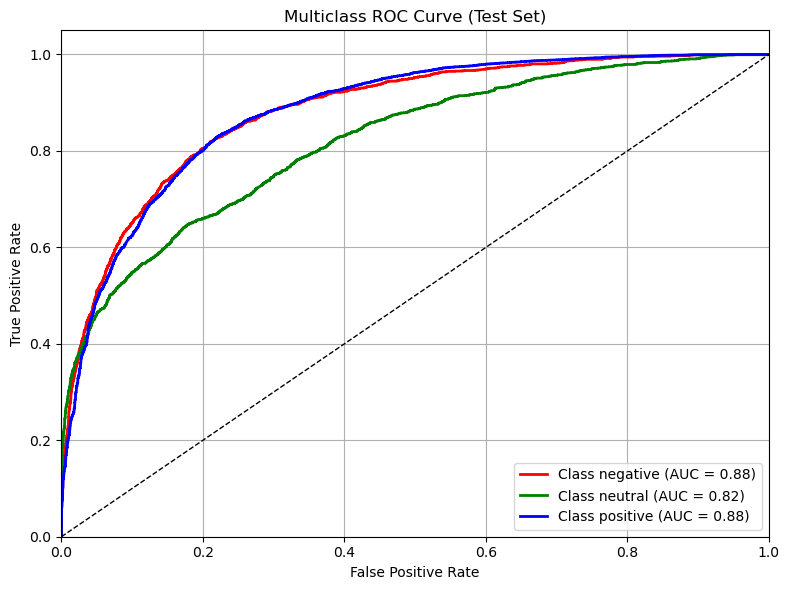

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Evaluate on training and test sets
_, y_train_true, y_train_pred, y_train_probs = evaluate(model, train_loader, criterion, device)
_, y_test_true, y_test_pred, y_test_probs = evaluate(model, test_loader, criterion, device)

# Binarize labels
y_train_bin = label_binarize(y_train_true, classes=[0, 1, 2])
y_test_bin = label_binarize(y_test_true, classes=[0, 1, 2])

# AUC Scores
train_auc = roc_auc_score(y_train_bin, y_train_probs, multi_class="ovr")
test_auc = roc_auc_score(y_test_bin, y_test_probs, multi_class="ovr")

# Accuracy
train_acc = (y_train_pred == y_train_true).sum().item() / len(y_train_true)
test_acc = (y_test_pred == y_test_true).sum().item() / len(y_test_true)

# Classification reports and confusion matrices
train_report = classification_report(y_train_true, y_train_pred, target_names=label_encoder.classes_)
test_report = classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_)

train_cm = confusion_matrix(y_train_true, y_train_pred)
test_cm = confusion_matrix(y_test_true, y_test_pred)

# Print Metrics
print("Training Metrics")
print(train_report)
print("Confusion Matrix:\n", train_cm)
print("AUC:", train_auc)
print("Accuracy:", train_acc)

print("\nTest Metrics")
print(test_report)
print("Confusion Matrix:\n", test_cm)
print("AUC:", test_auc)
print("Accuracy:", test_acc)

# === Plot ROC Curves for Test Set ===
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(3):  # For each class
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {label_encoder.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


Performance Summary
Overall Accuracy:
Training Accuracy: ~75.1%

Test Accuracy: ~73.1%


 AUC Score:
Train AUC: 0.90

Test AUC: 0.86

AUC > 0.85 indicates the model has a good ability to separate classes.

 F1-Score (Test):
Positive class: F1 = 0.83 (strong!)

Negative & Neutral: F1 = 0.60 and 0.53 (weaker but decent)

Confusion Matrix:
Positive class dominates accuracy — model struggles more with neutral and negative classes.

Training Trend Insights (Epoch-wise)
Epoch	Train Loss	Val Loss	Comment
1	0.7724	0.7825	Good start
5	0.7135	0.7504	Gap narrowing
10	0.6476	0.7458	Val loss flattening

The train loss is decreasing, but val loss is plateauing, which suggests nearing convergence.

 
